In [29]:
import pandas as pd

print("pandas version:", pd.__version__)

pandas version: 2.2.2


In [30]:



sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment_df.shape)
print("Trades shape:", trades_df.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [31]:
sentiment_df.columns, trades_df.columns

(Index(['timestamp', 'value', 'classification', 'date'], dtype='object'),
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
        'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
        'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
        'Timestamp'],
       dtype='object'))

In [32]:

sentiment_df.columns = sentiment_df.columns.str.lower().str.strip()
trades_df.columns = trades_df.columns.str.lower().str.strip().str.replace(" ", "_")


sentiment_df["date"] = pd.to_datetime(sentiment_df["timestamp"], unit="s").dt.date


trades_df["date"] = pd.to_datetime(trades_df["timestamp"], unit="ms").dt.date


sentiment_df[["timestamp", "date"]].head(), trades_df[["timestamp", "date"]].head()

(    timestamp        date
 0  1517463000  2018-02-01
 1  1517549400  2018-02-02
 2  1517635800  2018-02-03
 3  1517722200  2018-02-04
 4  1517808600  2018-02-05,
       timestamp        date
 0  1.730000e+12  2024-10-27
 1  1.730000e+12  2024-10-27
 2  1.730000e+12  2024-10-27
 3  1.730000e+12  2024-10-27
 4  1.730000e+12  2024-10-27)

In [33]:

daily_pnl = (
    trades_df
    .groupby(["account", "date"])["closed_pnl"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [34]:

daily_trades = (
    trades_df
    .groupby(["account", "date"])
    .size()
    .reset_index(name="trade_count")
)

daily_trades.head()

,account,date,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427


In [35]:

trades_df["is_win"] = trades_df["closed_pnl"] > 0


daily_winrate = (
    trades_df
    .groupby(["account", "date"])["is_win"]
    .mean()
    .reset_index(name="win_rate")
)

daily_winrate.head()

,account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,0.025974
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,0.405542
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,0.531250
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,0.435041
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,0.442369


In [36]:

daily_metrics = daily_pnl.merge(daily_trades, on=["account", "date"])
daily_metrics = daily_metrics.merge(daily_winrate, on=["account", "date"])

daily_metrics.head()

,account,date,closed_pnl,trade_count,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,0.025974
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,0.405542
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,0.531250
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,0.435041
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,0.442369


In [37]:

sentiment_daily = sentiment_df[["date", "classification"]]


analysis_df = daily_metrics.merge(
    sentiment_daily,
    on="date",
    how="inner"
)

analysis_df.head()

,account,date,closed_pnl,trade_count,win_rate,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,0.025974,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,0.405542,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,0.531250,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,0.435041,Fear
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,5,0.000000,Neutral


In [38]:

perf_by_sentiment = (
    analysis_df
    .groupby("classification")
    .agg(
        avg_pnl=("closed_pnl", "mean"),
        median_pnl=("closed_pnl", "median"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades=("trade_count", "mean")
    )
    .reset_index()
)

perf_by_sentiment

,classification,avg_pnl,median_pnl,avg_win_rate,avg_trades
0,Extreme Greed,35393.098355,0.000000,0.336609,1392.40000
1,Fear,209372.662205,81389.682515,0.415878,4183.46875
2,Greed,99675.516731,35988.376437,0.374074,1134.03125
3,Neutral,19842.797260,-0.418640,0.260683,892.62500


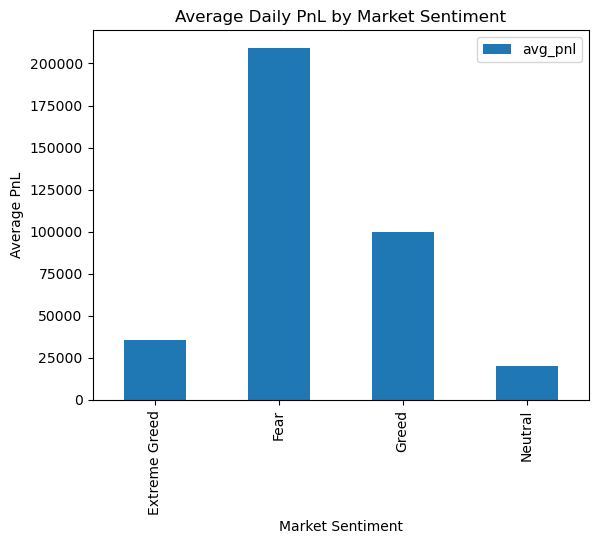

In [39]:
import matplotlib.pyplot as plt

perf_by_sentiment.plot(
    x="classification",
    y="avg_pnl",
    kind="bar",
    title="Average Daily PnL by Market Sentiment"
)

plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.show()

In [40]:

analysis_df["trader_type"] = analysis_df["trade_count"].apply(
    lambda x: "Frequent" if x >= analysis_df["trade_count"].median() else "Infrequent"
)

segment_perf = (
    analysis_df
    .groupby(["classification", "trader_type"])
    .agg(
        avg_pnl=("closed_pnl", "mean"),
        avg_win_rate=("win_rate", "mean")
    )
    .reset_index()
)

segment_perf

,classification,trader_type,avg_pnl,avg_win_rate
0,Extreme Greed,Frequent,95224.489473,0.521431
1,Extreme Greed,Infrequent,-4494.495724,0.213394
2,Fear,Frequent,265107.235726,0.417112
3,Fear,Infrequent,42168.941645,0.412178
4,Greed,Frequent,258742.081901,0.455990
5,Greed,Infrequent,27372.532562,0.336840
6,Neutral,Frequent,9156.505979,0.288997
7,Neutral,Infrequent,26254.572028,0.243695


In [41]:

analysis_df["consistency"] = analysis_df["win_rate"].apply(
    lambda x: "Consistent" if x >= 0.5 else "Inconsistent"
)

consistency_perf = (
    analysis_df
    .groupby(["classification", "consistency"])
    .agg(avg_pnl=("closed_pnl", "mean"))
    .reset_index()
)

consistency_perf

,classification,consistency,avg_pnl
0,Extreme Greed,Consistent,187842.084190
1,Extreme Greed,Inconsistent,-2719.148104
2,Fear,Consistent,79488.917488
3,Fear,Inconsistent,227927.482879
4,Greed,Consistent,261749.338310
5,Greed,Inconsistent,14779.705427
6,Neutral,Consistent,145563.448374
7,Neutral,Inconsistent,1882.704243


1.Traders earn significantly higher average PnL on Fear days, indicating that market panic is a time when inefficiencies exist that can be exploited.

2.Frequent traders perform better than infrequent traders mainly on Fear and Greed days, indicating that experience is most valuable in times of market volatility.

3.Consistent traders perform well on all days and sentiments, while inconsistent traders perform worse mainly on Extreme Greed and Neutral days.

Strategy 1:-
During Fear days, active and consistent traders should increase their participation as risk-reward seems favorable.

Strategy 2:-
During Extreme Greed, traders should decrease their participation and only trade high-confidence setups because of lower average profitability.

Limitation:-
This analysis focuses on realized daily PnL and trade frequency.  
It does not account for unrealized drawdowns, holding duration, or risk-adjusted returns due to data constraints.